In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt

c:\Users\Melih\Desktop\LeVİT_env\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = 'flowers'
batch_size = 32
img_size = 224
num_epochs = 5

In [12]:
train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = datasets.ImageFolder(os.path.join(data_dir), transform=train_transforms)
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
val_dataset.dataset.transform = test_transforms

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [13]:
num_classes = len(train_dataset.dataset.classes)

model = timm.create_model('maxvit_tiny_rw_224.sw_in1k', pretrained=True, num_classes=num_classes)
model = model.to(device)

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3)

In [15]:
train_acc_list, val_acc_list = [], []

for epoch in range(num_epochs):
    model.train()
    train_correct, train_total = 0, 0
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_acc_list.append(train_acc)

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_acc_list.append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

Epoch 1/5 - Train Acc: 0.6370 - Val Acc: 0.6779
Epoch 2/5 - Train Acc: 0.8089 - Val Acc: 0.8151
Epoch 3/5 - Train Acc: 0.8672 - Val Acc: 0.7666
Epoch 4/5 - Train Acc: 0.8831 - Val Acc: 0.7703
Epoch 5/5 - Train Acc: 0.9062 - Val Acc: 0.7946


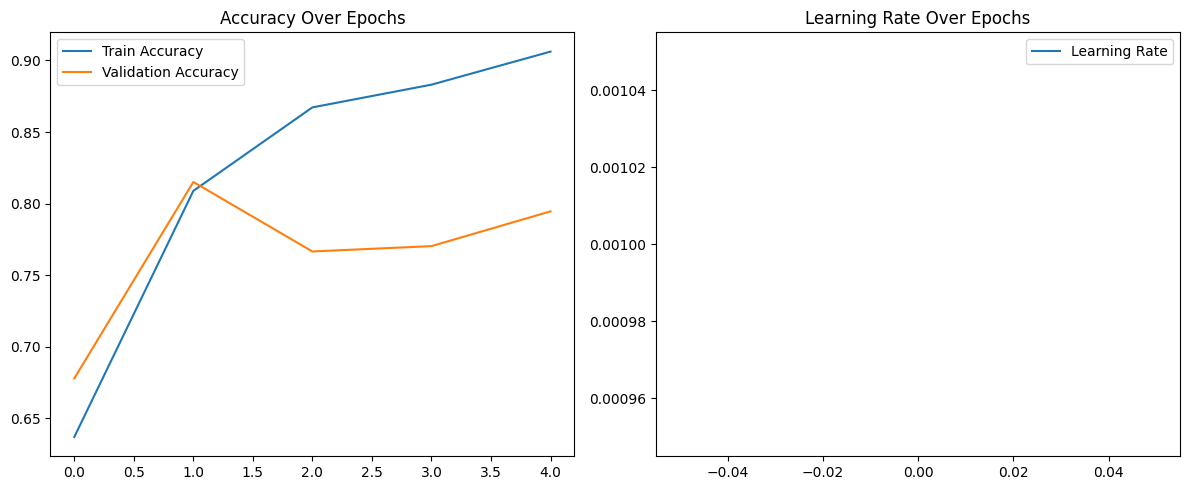

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(val_acc_list, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1, 2, 2)
plt.plot(scheduler._last_lr, label='Learning Rate')
plt.legend()
plt.title('Learning Rate Over Epochs')

plt.tight_layout()
plt.show()

In [17]:
torch.save(model.state_dict(), 'maxvit_flower_classifier.pth')